In [1]:
!pip install opencv-python

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import cv2 

In [3]:
df = pd.read_csv("train-labels.csv")

df.head()

,Unnamed: 0,image,text
0,0,train-0.png,BU522X
1,1,train-1.png,XQ8NE2
2,2,train-2.png,DTZD3E
3,3,train-3.png,SM424H
4,4,train-4.png,6YVTQR


In [4]:
row = df.iloc[0]

img = cv2.imread(
    f"train_images/{row['image']}",
    cv2.IMREAD_GRAYSCALE)

print("Shape:", img.shape)
print("Type:", img.dtype)
print("Min:", img.min())
print("Max:", img.max())

Shape: (100, 200)
Type: uint8
Min: 0
Max: 240


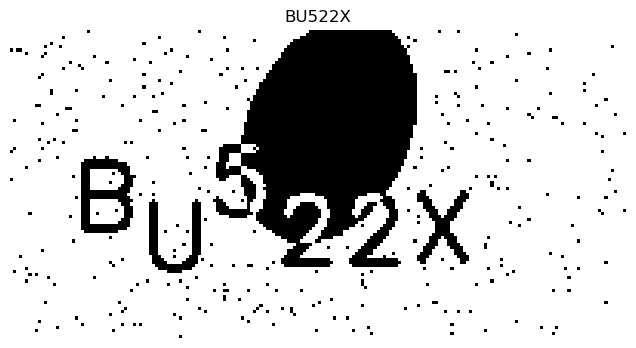

In [5]:
plt.figure(figsize=(8,4))

plt.imshow(img,cmap="gray")

plt.title(row["text"])

plt.axis("off")

plt.show()

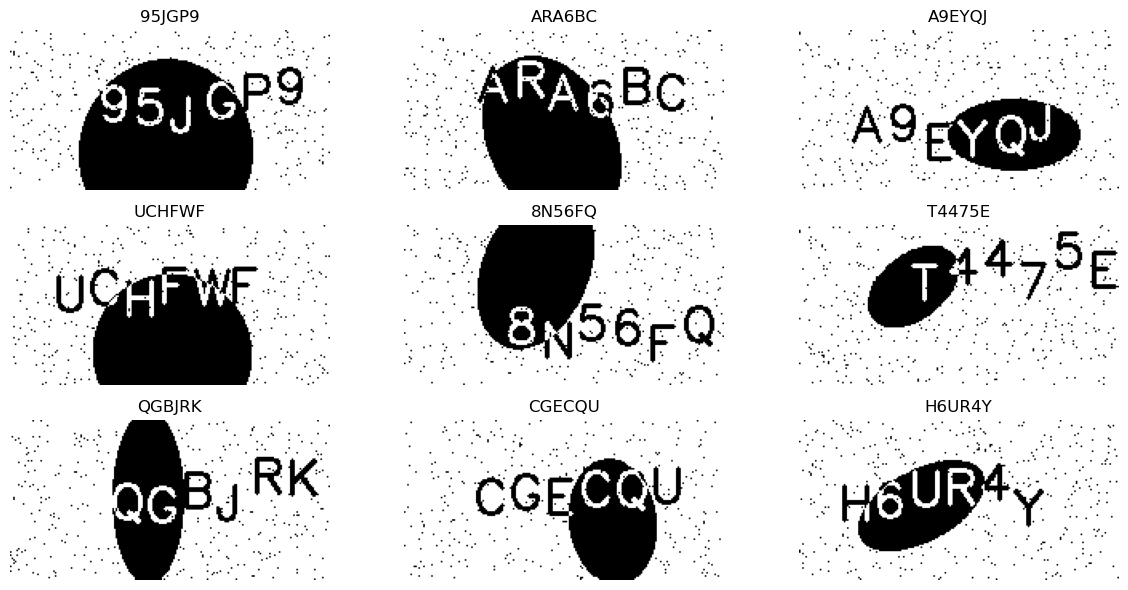

In [6]:
fig, axes = plt.subplots(3, 3, figsize=(12,6))

for ax in axes.flatten():

    idx = np.random.randint(len(df))
    row = df.iloc[idx]
    img = cv2.imread(
        f"train_images/{row['image']}",
        cv2.IMREAD_GRAYSCALE)

    ax.imshow(img, cmap="gray")
    ax.set_title(row["text"])
    ax.axis("off")

plt.tight_layout()
plt.show()

In [7]:
df["text"].str.len().value_counts()

text
6    19998
8        1
9        1
Name: count, dtype: int64

In [8]:
df[df["text"].str.len() != 6]

,Unnamed: 0,image,text
2184,2184,train-2184.png,5.40E+12
6819,6819,train-6819.png,04-Mar-54


In [9]:
df = df[df["text"].str.len() == 6].copy()

print(len(df))

19998


In [10]:
df["text"].str.len().value_counts()

text
6    19998
Name: count, dtype: int64

In [11]:
all_chars = "".join(df["text"])

characters = sorted(set(all_chars))

print(characters)
print("Number of characters:", len(characters))

['2', '3', '4', '5', '6', '7', '8', '9', 'A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'J', 'K', 'M', 'N', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z']
Number of characters: 31


In [12]:
from collections import Counter

counter = Counter("".join(df["text"]))

print(counter)

Counter({'7': 3989, 'E': 3965, 'X': 3956, 'G': 3942, 'Y': 3936, '2': 3925, 'M': 3925, 'W': 3916, 'F': 3913, 'N': 3904, 'S': 3889, 'J': 3886, 'R': 3883, '4': 3881, 'D': 3880, 'Q': 3873, 'C': 3861, 'Z': 3860, 'H': 3845, '6': 3842, 'T': 3841, 'V': 3838, 'P': 3836, '5': 3830, '3': 3826, 'A': 3819, 'U': 3812, '8': 3811, 'B': 3805, 'K': 3753, '9': 3746})


In [13]:
img.shape

(100, 200)